In [1]:
import pandas as pd 
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf
import keras
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers , models
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import TensorBoard , ModelCheckpoint



In [2]:
train_path = r"E:\grad_project\Dental_X-ray panoramic\train\train_images"
val_path   = r"E:\grad_project\Dental_X-ray panoramic\valid\valid_images"

labels_df = pd.read_csv(r"E:\grad_project\train_cleaned.csv")
val_df = pd.read_csv(r"E:\grad_project\validation_cleaned.csv")


labels_df['image_path'] = labels_df['image_name'].apply(lambda x: os.path.join(train_path, x))
val_df['image_path'] = val_df['image_name'].apply(lambda x: os.path.join(val_path, x))

labels_df.drop(['image_name'], axis=1, inplace=True)
val_df.drop(['image_name'], axis=1, inplace=True)
labels_df.head()

,Caries,Crown,Filling,Implant,Mandibular Canal,Missing teeth,Periapical lesion,Root Canal Treatment,Root Piece,impacted tooth,maxillary sinus,image_path
0,0,0,1,0,0,0,0,0,0,1,0,E:\grad_project\Dental_X-ray panoramic\train\t...
1,0,0,1,0,0,0,0,1,0,1,0,E:\grad_project\Dental_X-ray panoramic\train\t...
2,0,0,1,0,0,0,0,0,0,1,0,E:\grad_project\Dental_X-ray panoramic\train\t...
3,0,1,1,0,0,1,0,1,0,1,0,E:\grad_project\Dental_X-ray panoramic\train\t...
4,0,0,1,0,0,0,0,0,0,1,0,E:\grad_project\Dental_X-ray panoramic\train\t...


In [3]:
images_train = os.listdir(train_path)
images_val = os.listdir(val_path)
print(f"images_train:{len(images_train)} | images_val:{len(images_val)}")

images_train:4768 | images_val:2071


In [4]:
print("Train missing:", (~labels_df['image_path'].apply(os.path.exists)).sum())
print("Val missing:",   (~val_df['image_path'].apply(os.path.exists)).sum())


Train missing: 0
Val missing: 0


In [5]:
labels_columns = ['Caries','Crown','Filling','Implant','Mandibular Canal',
               'Missing teeth','Periapical lesion','Root Canal Treatment',
               'Root Piece','impacted tooth','maxillary sinus']

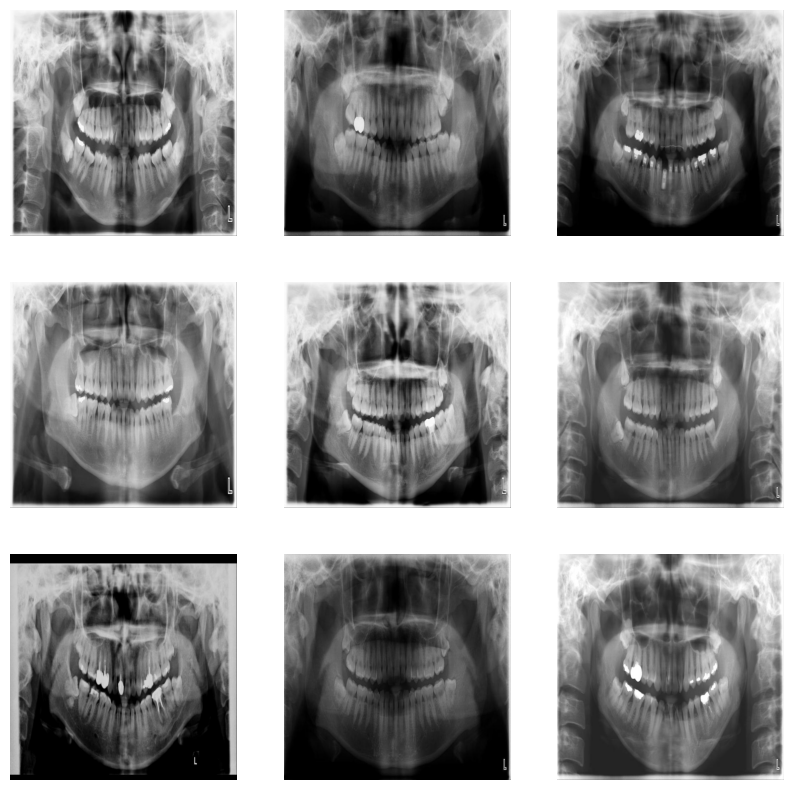

In [6]:
sample_images = random.sample(images_train, 9)

plt.figure(figsize=(10,10))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(train_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [7]:
shapes_set = set()

for img_name in images_train:
    img_path = os.path.join(train_path, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        shapes_set.add(img.shape)  # shape = (height, width, channels) 3for color images , 1 for grayscale

print(f"numper of shapes: {len(shapes_set)}")
print("shapes in the dataset:")
for s in shapes_set:
    print(s)

numper of shapes: 1
shapes in the dataset:
(640, 640, 3)


In [8]:
IMG_SIZE = 320

def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)  
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image) 
    return image, label 

In [9]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])

In [10]:
def preprocess_and_augment(path, label):
    image, label = load_and_preprocess(path, label)
    image = data_augmentation(image) 
    return image, label


In [ ]:
BATCH_SIZE = 32

# convert labels to float32 for TensorFlow
labels_df[labels_columns] = labels_df[labels_columns].astype('float32')

train_dataset = tf.data.Dataset.from_tensor_slices(
    (labels_df['image_path'].values,
     labels_df[labels_columns].values)
)
train_dataset = train_dataset.cache()
train_dataset = train_dataset.shuffle(1000)  # 1000 => is a buffer size for shuffle
train_dataset = train_dataset.map(preprocess_and_augment, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [12]:
val_dataset = tf.data.Dataset.from_tensor_slices((
    val_df['image_path'].values,
    val_df[labels_columns].values
))
val_dataset = val_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Images shape: (32, 320, 320, 3)
Labels shape: (32, 11)


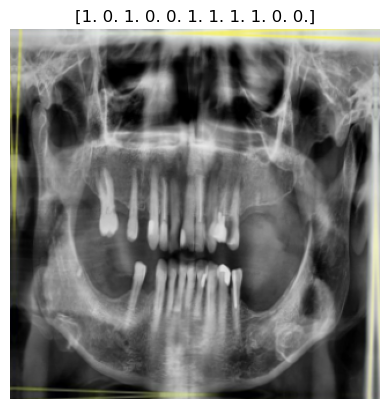

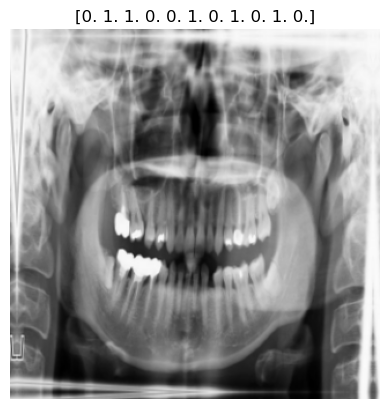

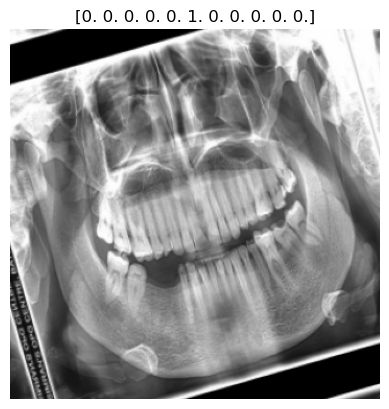

In [13]:
# Visualize a batch of augmented images and their labels
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    
    for i in range(3):
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(labels[i].numpy())
        plt.axis('off')
        plt.show()


In [14]:
train_dataset = train_dataset.cache('E:/tf_cache')  


In [ ]:
checkpoint_cb = ModelCheckpoint(
    filepath='E:/models/efficientnetb0_best.keras',
    save_best_only=True,
    monitor='val_loss'
)


In [16]:
tensorboard_cb = TensorBoard(log_dir='E:/logs/efficientnetb0')

In [17]:
num_classes = len(labels_columns)

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # freeze initial layers

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=[
    tf.keras.metrics.BinaryAccuracy(),
    tf.keras.metrics.AUC(),
]
)


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[checkpoint_cb, tensorboard_cb]

)


Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - auc: 0.8187 - binary_accuracy: 0.7878 - loss: 0.4476

149/149 ━━━━━━━━━━━━━━━━━━━━ 116s 738ms/step - auc: 0.8190 - binary_accuracy: 0.7880 - loss: 0.4473 - val_auc: 0.9236 - val_binary_accuracy: 0.8775 - val_loss: 0.3041
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - auc: 0.8985 - binary_accuracy: 0.8437 - loss: 0.3485

149/149 ━━━━━━━━━━━━━━━━━━━━ 101s 676ms/step - auc: 0.8985 - binary_accuracy: 0.8437 - loss: 0.3485 - val_auc: 0.9304 - val_binary_accuracy: 0.8816 - val_loss: 0.2949
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - auc: 0.9086 - binary_accuracy: 0.8539 - loss: 0.3323

149/149 ━━━━━━━━━━━━━━━━━━━━ 131s 882ms/step - auc: 0.9086 - binary_accuracy: 0.8539 - loss: 0.3323 - val_auc: 0.9322 - val_binary_accuracy: 0.8831 - val_loss: 0.2903
Epoch 4/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - auc: 0.9150 - binary_accuracy: 0.8589 - loss: 0.3215

149/149 ━━━━━━━━━━━━━━━━━━━━ 100s 670ms/step - auc: 0.9150 - binary_accuracy: 0.8589 - loss: 0.3215 - val_auc: 0.9327 - val_binary_accuracy: 0.8829 - val_loss: 0.2898
Epoch 5/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - auc: 0.9178 - binary_accuracy: 0.8607 - loss: 0.3164

149/149 ━━━━━━━━━━━━━━━━━━━━ 99s 668ms/step - auc: 0.9178 - binary_accuracy: 0.8607 - loss: 0.3164 - val_auc: 0.9334 - val_binary_accuracy: 0.8842 - val_loss: 0.2867
Epoch 6/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 109s 730ms/step - auc: 0.9205 - binary_accuracy: 0.8617 - loss: 0.3116 - val_auc: 0.9329 - val_binary_accuracy: 0.8838 - val_loss: 0.2877
Epoch 7/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 106s 710ms/step - auc: 0.9231 - binary_accuracy: 0.8653 - loss: 0.3068 - val_auc: 0.9329 - val_binary_accuracy: 0.8832 - val_loss: 0.2883
Epoch 8/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 121s 815ms/step - auc: 0.9250 - binary_accuracy: 0.8674 - loss: 0.3033 - val_auc: 0.9325 - val_binary_accuracy: 0.8822 - val_loss: 0.2889
Epoch 9/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - auc: 0.9260 - binary_accuracy: 0.8683 - loss: 0.3018 - val_auc: 0.9326 - val_binary_accuracy: 0.8834 - val_loss: 0.2881
Epoch 10/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - auc: 0.9263 - binary_accuracy: 0.8699 - loss: 0.3004 - val_auc: 0.932

149/149 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - auc: 0.9269 - binary_accuracy: 0.8703 - loss: 0.2990 - val_auc: 0.9327 - val_binary_accuracy: 0.8828 - val_loss: 0.2867
Epoch 12/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - auc: 0.9283 - binary_accuracy: 0.8709 - loss: 0.2969 - val_auc: 0.9316 - val_binary_accuracy: 0.8824 - val_loss: 0.2902
Epoch 13/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 845ms/step - auc: 0.9304 - binary_accuracy: 0.8718 - loss: 0.2932

149/149 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - auc: 0.9304 - binary_accuracy: 0.8718 - loss: 0.2932 - val_auc: 0.9326 - val_binary_accuracy: 0.8837 - val_loss: 0.2857
Epoch 14/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 134s 903ms/step - auc: 0.9296 - binary_accuracy: 0.8722 - loss: 0.2944 - val_auc: 0.9318 - val_binary_accuracy: 0.8830 - val_loss: 0.2888
Epoch 15/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 144s 970ms/step - auc: 0.9289 - binary_accuracy: 0.8718 - loss: 0.2956 - val_auc: 0.9319 - val_binary_accuracy: 0.8833 - val_loss: 0.2873
Epoch 16/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 139s 934ms/step - auc: 0.9309 - binary_accuracy: 0.8717 - loss: 0.2917 - val_auc: 0.9309 - val_binary_accuracy: 0.8817 - val_loss: 0.2918
Epoch 17/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 141s 948ms/step - auc: 0.9309 - binary_accuracy: 0.8741 - loss: 0.2915 - val_auc: 0.9318 - val_binary_accuracy: 0.8829 - val_loss: 0.2882
Epoch 18/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 134s 897ms/step - auc: 0.9321 - binary_accuracy: 0.8742 - loss: 0.2893 - val_au

In [20]:
model.save('E:/grad_project/efficientnetb0_final.keras')

In [22]:
from tensorflow.keras.models import load_model

final_model = load_model('E:/grad_project/efficientnetb0_final.keras')

c:\Users\DELL\anaconda3\envs\ds_ai_env\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [23]:
IMG_SIZE = 320
def prepare_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    img = tf.expand_dims(img, axis=0)  # عشان يبقى  batch (1, 320, 320, 3)                         هو هو حلمي يا عم
    return img


In [ ]:
image_path = r"E:\grad_project\Dental_X-ray panoramic\test\test_images\3ba9dff3-SALEMI_HAMIDREZA_2020-07-12203357_jpg.rf.a9597cd76631b3a3e5aadf47c526c647.jpg"
img = prepare_image(image_path)

pred = final_model.predict(img)
print("Predicted probabilities:", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted probabilities: [[0.8107981  0.04531753 0.58186126 0.00150172 0.03007391 0.05015876
  0.26863447 0.1855336  0.07642405 0.35602424 0.00415892]]


In [29]:
labels = [
    "Caries", "Crown", "Filling", "Implant",
    "Mandibular Canal", "Missing teeth",
    "Periapical lesion", "Root Canal Treatment",
    "Root Piece", "Impacted tooth", "Maxillary sinus"
]

threshold = 0.5

for i, prob in enumerate(pred[0]):
    if prob > threshold:
        print(f"{labels[i]} : {prob:.2f}")


Caries : 0.81
Filling : 0.58
